In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.0566369   7.73020385 11.07420845 13.12309129 17.41456479
 17.57786409 25.51228464 25.51356975 36.14800094 36.14800387]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [25]:
def sim_pulse(f_d,A,evolution,dim,f_rabi,K=20):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_d,f_ef,[pulses.one],[N_pulse],time_unit=dt,offset_input=0)
    U_floquet=evolution.U_floquet(A*pulse.raw[0:K],dt)
    
    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1
    psi = np.zeros((N_sim, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
    psi[0,0] = 1
    
    #Simulaatio pulsseille
    for i in range(1,N_sim):
        psi[i] = U_floquet @ psi[i-1] #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([np.abs(a[1])**2 for a in psi])
    f_vals = np.array([np.abs(a[2])**2 for a in psi])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,psi,pulse_times)

def find_params(q,A,evolution,f_rabi,AC_stark):

    #Rajat AC-stark siirtymälle
    min_range = -1000
    max_range = 10000

    f_d = q.frequency/3 #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/1000 #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse(f_d+delta,A,evolution,dim,f_rabi)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=f_d-f_q/3 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

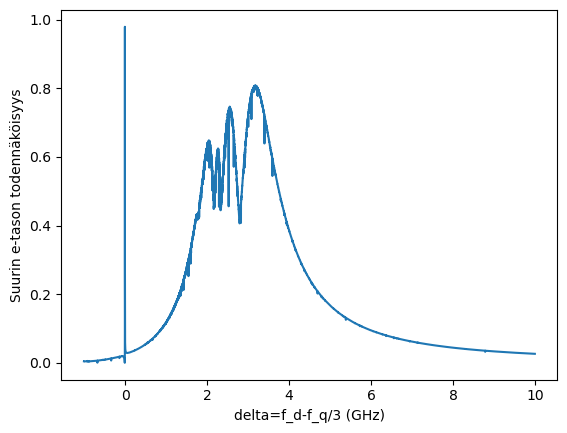

Amplitudi (GHz): 0.811327380727859
AC-stark siirtymä (GHz): -0.008178574619266151
E-tason suurin todennäköisyys: 0.979294538187771
Pulssin pituus (ns): 2253.2881862538065
Rabi-taajuus (fourier):  0.00022099404907128603


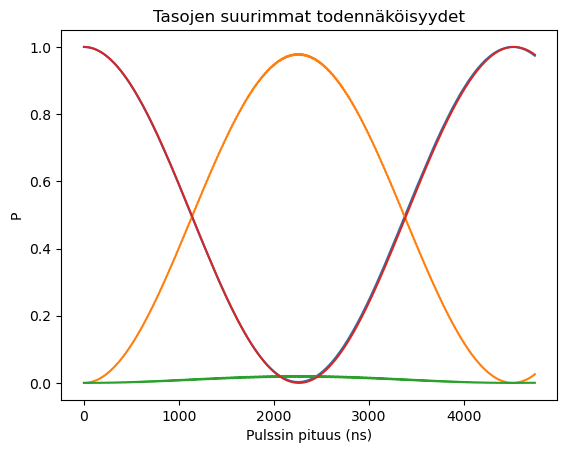

---------------------------------------------


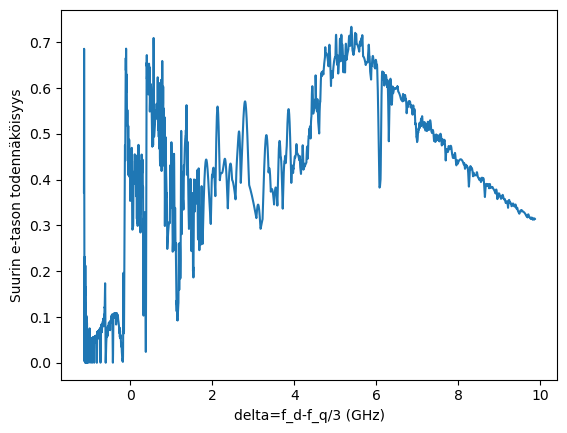

Amplitudi (GHz): 3.0424776777294715
AC-stark siirtymä (GHz): 5.390786615558306
E-tason suurin todennäköisyys: 0.7375504605593456
Pulssin pituus (ns): 27.02245338568919
Rabi-taajuus (fourier):  0.4618346843250812


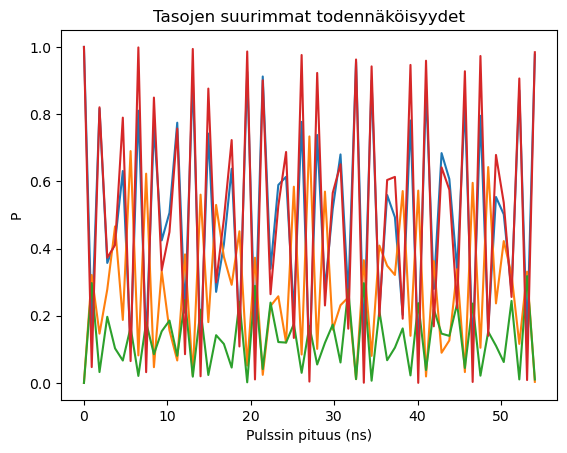

---------------------------------------------


In [26]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.20
max_range = 0.75
N_data=2
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_rabi=0.001294*A**3 - 0.002922*A**2 + 0.003197*A - 0.001151 #Arvaus Rabi-taajuudelle
    AC_stark=-0.0148*A**2 + 0.001444*A + 0.001392 #Arvaus AC-stark siirtymälle
    params=find_params(qubit, A, evolution_eigenbasis,f_rabi,AC_stark)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    max_vals.append(params[2])
    data.append(params[3])
    
    f_d_opt = qubit.frequency/3+deltas[-1] #Löydetty optimaalinen ajotaajuus

    vals=sim_pulse(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/100)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
    e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
    f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    T_floquet = 2*np.pi/(f_d_opt)
    freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/100) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

In [ ]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=f_d-f_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

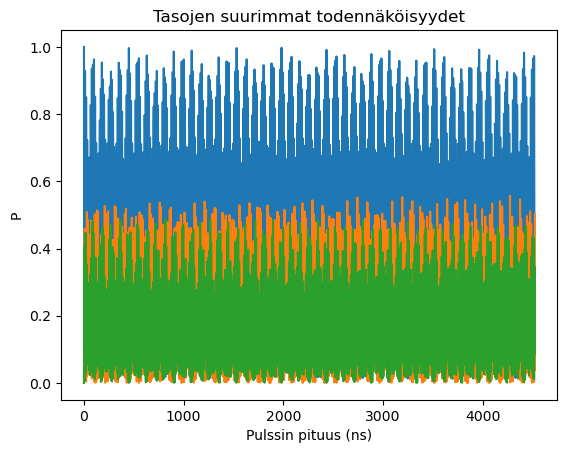

---------------------------------------------


In [28]:
vals=sim_pulse(qubit.frequency,A_vals[0],evolution_eigenbasis,dim,rabis[0])

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

plt.figure()
plt.plot(vals[4], g_vals)
plt.plot(vals[4], e_vals)
plt.plot(vals[4], f_vals)
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

In [29]:
qubit.frequency-qubit.frequency/3

np.float64(2.7044246024261964)